# 01 - Exploratory Data Analysis (EDA)
## Sistem POS Terintegrasi Machine Learning untuk Optimasi Manajemen Stok UMKM

**Penulis:** Mita Salsabilla & Yafi Rizky Kurniawan  
**Program Studi:** D3 Teknik Informatika - Politeknik Negeri Semarang  
**Tanggal:** Juli 2026

---

### Tujuan Notebook Ini
1. Memahami karakteristik data produk UMKM dari hasil wawancara
2. Menganalisis pola transaksi harian, mingguan, dan bulanan
3. Mengidentifikasi produk fast-moving vs slow-moving
4. Menyiapkan insight awal untuk pemilihan model Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load data
products = pd.read_csv('data/compiled_products.csv')
transactions = pd.read_csv('data/transactions.csv')
items = pd.read_csv('data/transaction_items.csv')
batches = pd.read_csv('data/batches.csv')

# Parse dates
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['datetime'] = pd.to_datetime(transactions['datetime'])
batches['purchase_date'] = pd.to_datetime(batches['purchase_date'])
batches['expiry_date'] = pd.to_datetime(batches['expiry_date'])

print(f'Jumlah Produk: {len(products)}')
print(f'Jumlah Transaksi: {len(transactions)}')
print(f'Jumlah Item Terjual: {len(items)}')
print(f'Jumlah Batch Stok: {len(batches)}')
print(f'\nRentang Waktu: {transactions["date"].min()} - {transactions["date"].max()}')
print(f'Total Hari: {transactions["date"].nunique()}')

Jumlah Produk: 24
Jumlah Transaksi: 1802
Jumlah Item Terjual: 4292
Jumlah Batch Stok: 329

Rentang Waktu: 2026-04-01 00:00:00 - 2026-06-30 00:00:00
Total Hari: 91


## 2. Profil Produk UMKM

In [3]:
# Tampilkan semua produk
display_cols = ['code', 'name', 'category', 'buy', 'sell', 'unit', 'source']
products[display_cols].style.set_caption('Tabel 1: Daftar Produk dari Wawancara UMKM')

,code,name,category,buy,sell,unit,source
0,SMB01,Gula Pasir 1kg,Sembako,13500,15500,kg,Toko Amanah
1,SMB02,Minyak Goreng 1L,Sembako,13500,15000,liter,Toko Barokah
2,SMB03,Tepung Beras,Sembako,3300,4000,bungkus,Toko Barokah
3,SMB04,Kecap Manis,Sembako,3300,4000,bungkus,Toko Barokah
4,MIE01,Indomie Goreng,Mie Instan,2500,3000,pcs,Toko Barokah
5,MIE02,Mie Sedap Goreng,Mie Instan,2500,3000,pcs,Toko Barokah
6,MIE03,Mie Sedap Soto Ayam,Mie Instan,2750,3500,pcs,Toko Moro
7,MIE04,Mie Sedap Cup Soto,Mie Instan,4500,5500,pcs,Toko Moro
8,MNM01,Aqua Botol 600ml,Minuman,3000,4000,pcs,Toko Amanah
9,MNM02,Teh Pucuk Harum,Minuman,3000,4000,pcs,Toko Moro


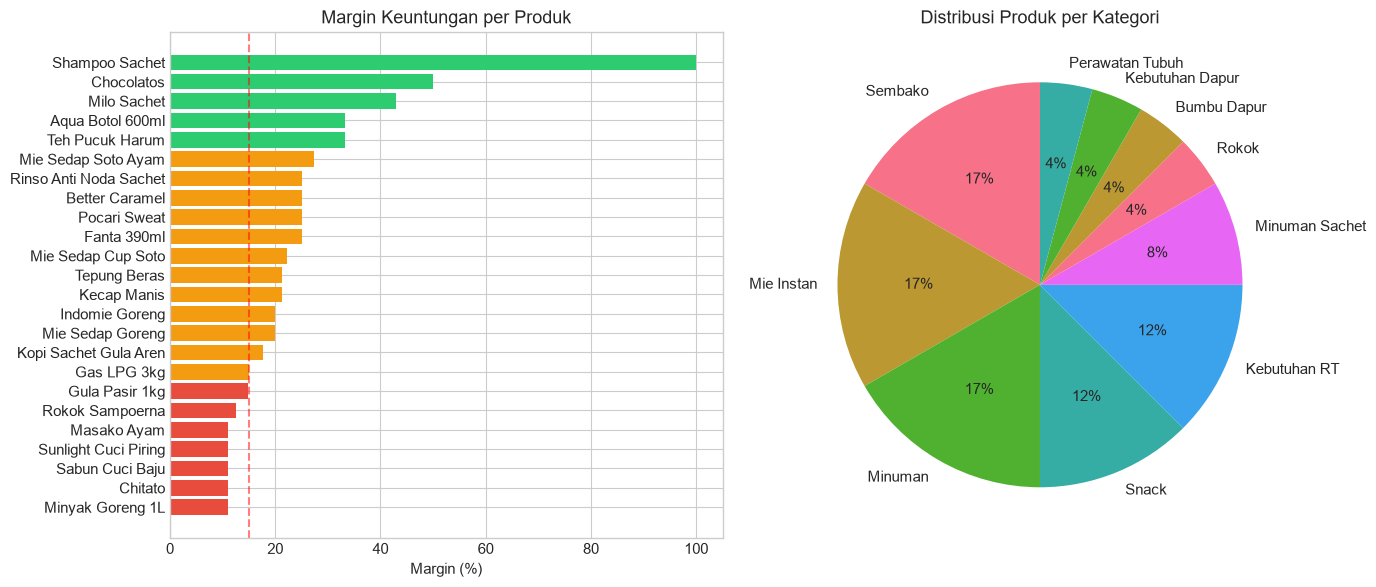


Rata-rata margin: 25.3%
Margin tertinggi: Shampoo Sachet (100.0%)
Margin terendah: Minyak Goreng 1L (11.1%)


In [4]:
# Margin per produk
products['margin'] = products['sell'] - products['buy']
products['margin_pct'] = ((products['sell'] - products['buy']) / products['buy'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Margin percentage
sorted_prods = products.sort_values('margin_pct', ascending=True)
colors = ['#e74c3c' if m < 15 else '#2ecc71' if m > 30 else '#f39c12' for m in sorted_prods['margin_pct']]
axes[0].barh(sorted_prods['name'], sorted_prods['margin_pct'], color=colors)
axes[0].set_xlabel('Margin (%)')
axes[0].set_title('Margin Keuntungan per Produk')
axes[0].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Margin Tipis (<15%)')

# Chart 2: Distribusi kategori
cat_counts = products['category'].value_counts()
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.0f%%', startangle=90)
axes[1].set_title('Distribusi Produk per Kategori')

plt.tight_layout()
plt.savefig('data/eda_margin_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRata-rata margin: {products["margin_pct"].mean():.1f}%')
print(f'Margin tertinggi: {products.loc[products["margin_pct"].idxmax(), "name"]} ({products["margin_pct"].max():.1f}%)')
print(f'Margin terendah: {products.loc[products["margin_pct"].idxmin(), "name"]} ({products["margin_pct"].min():.1f}%)')

## 3. Analisis Transaksi Harian

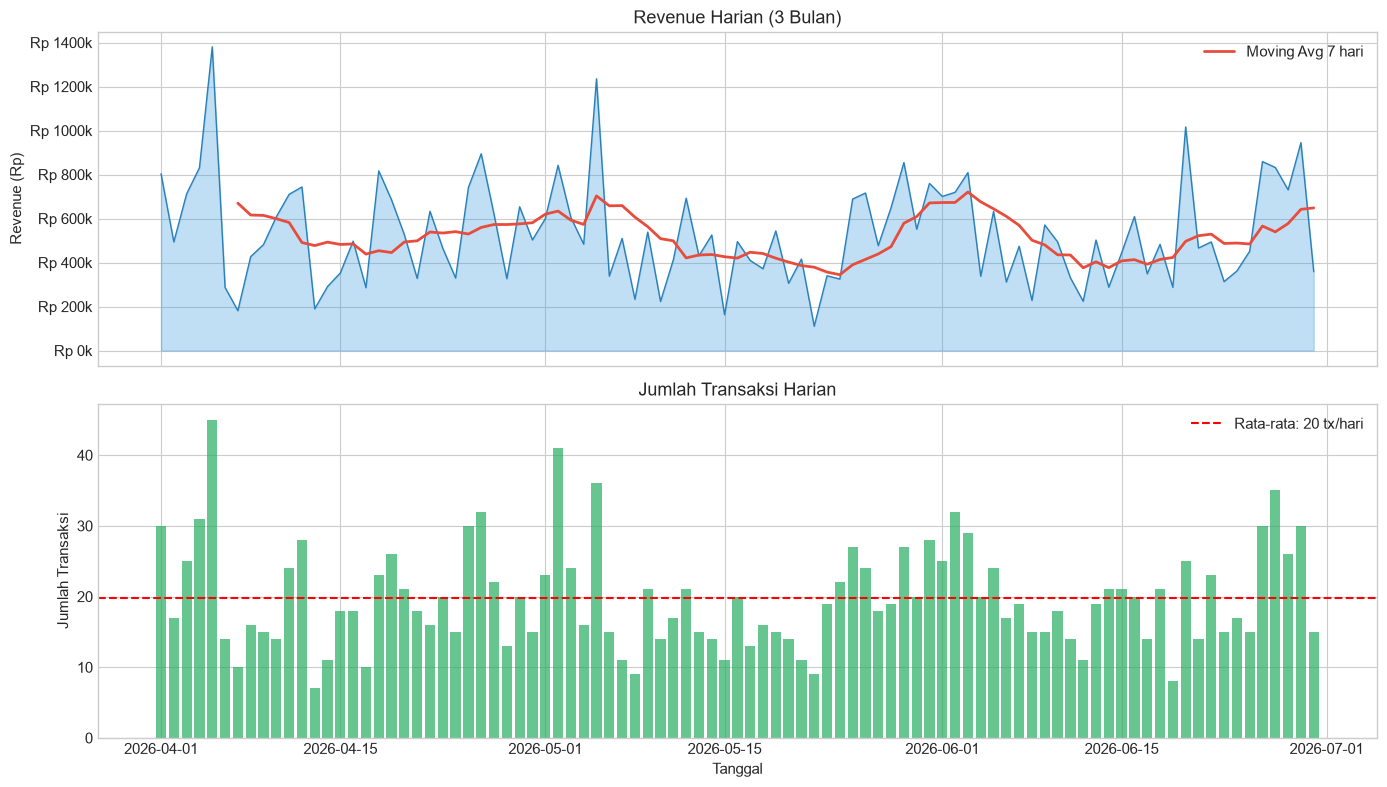


Statistik Revenue Harian:
  Rata-rata: Rp 530,232
  Minimum:   Rp 110,350
  Maximum:   Rp 1,380,350
  Std Dev:   Rp 233,746


In [5]:
# Revenue harian
daily_revenue = transactions.groupby('date')['total'].sum().reset_index()
daily_revenue.columns = ['date', 'revenue']
daily_tx_count = transactions.groupby('date').size().reset_index(name='tx_count')
daily = daily_revenue.merge(daily_tx_count, on='date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Revenue harian
axes[0].fill_between(daily['date'], daily['revenue'], alpha=0.3, color='#3498db')
axes[0].plot(daily['date'], daily['revenue'], color='#2980b9', linewidth=1)
axes[0].plot(daily['date'], daily['revenue'].rolling(7).mean(), color='#e74c3c', linewidth=2, label='Moving Avg 7 hari')
axes[0].set_ylabel('Revenue (Rp)')
axes[0].set_title('Revenue Harian (3 Bulan)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x/1000:.0f}k'))

# Jumlah transaksi harian
axes[1].bar(daily['date'], daily['tx_count'], alpha=0.7, color='#27ae60')
axes[1].axhline(y=daily['tx_count'].mean(), color='red', linestyle='--', label=f'Rata-rata: {daily["tx_count"].mean():.0f} tx/hari')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xlabel('Tanggal')
axes[1].set_title('Jumlah Transaksi Harian')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/eda_revenue_harian.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStatistik Revenue Harian:')
print(f'  Rata-rata: Rp {daily["revenue"].mean():,.0f}')
print(f'  Minimum:   Rp {daily["revenue"].min():,.0f}')
print(f'  Maximum:   Rp {daily["revenue"].max():,.0f}')
print(f'  Std Dev:   Rp {daily["revenue"].std():,.0f}')

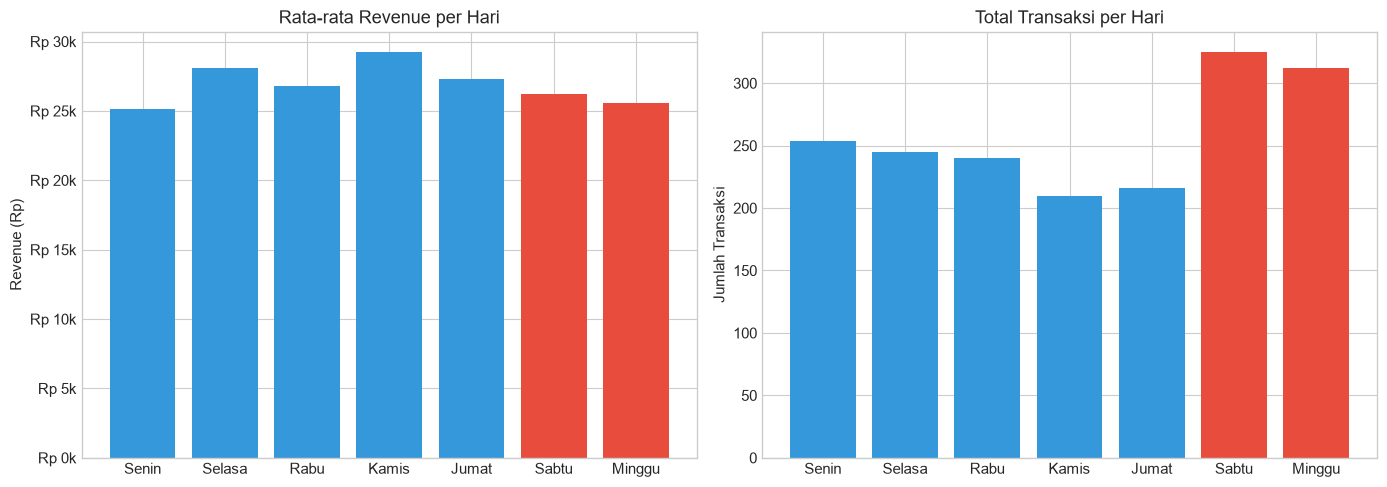

Insight: Weekend (Sabtu-Minggu) menunjukkan peningkatan transaksi dan revenue


In [6]:
# Pola mingguan
day_names = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
weekly = transactions.groupby('day_of_week')['total'].agg(['sum', 'mean', 'count']).reset_index()
weekly['day_name'] = [day_names[i] for i in weekly['day_of_week']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_week = ['#3498db']*5 + ['#e74c3c']*2  # Weekend merah
axes[0].bar(weekly['day_name'], weekly['mean'], color=colors_week)
axes[0].set_title('Rata-rata Revenue per Hari')
axes[0].set_ylabel('Revenue (Rp)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x/1000:.0f}k'))

axes[1].bar(weekly['day_name'], weekly['count'], color=colors_week)
axes[1].set_title('Total Transaksi per Hari')
axes[1].set_ylabel('Jumlah Transaksi')

plt.tight_layout()
plt.savefig('data/eda_pola_mingguan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Weekend (Sabtu-Minggu) menunjukkan peningkatan transaksi dan revenue')

## 4. Analisis Produk: Fast vs Slow Moving

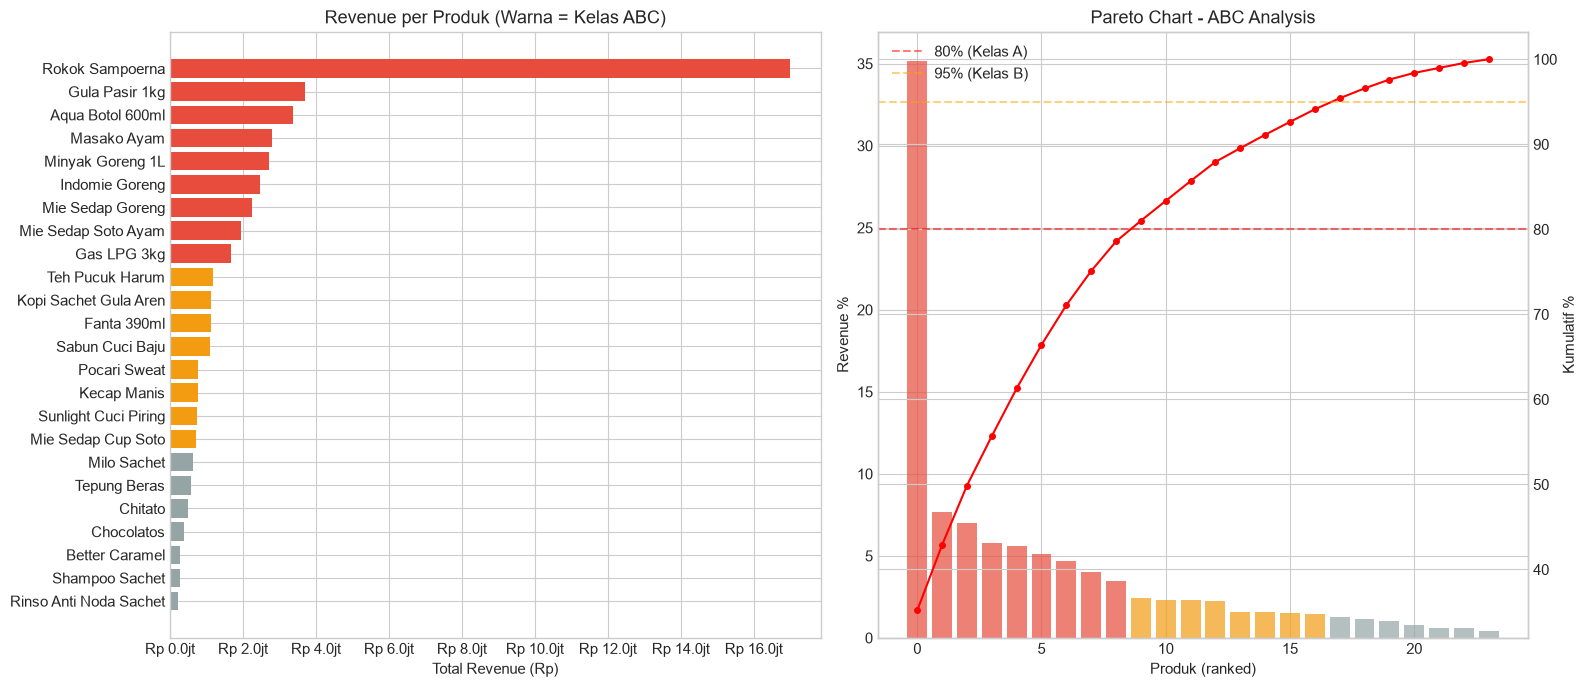


Klasifikasi ABC:
  Kelas A: 9 produk, 78.6% revenue
    - Rokok Sampoerna: Rp 16,980,300 (35.2%)
    - Gula Pasir 1kg: Rp 3,710,700 (7.7%)
    - Aqua Botol 600ml: Rp 3,371,600 (7.0%)
    - Masako Ayam: Rp 2,803,750 (5.8%)
    - Minyak Goreng 1L: Rp 2,705,250 (5.6%)
    - Indomie Goreng: Rp 2,475,000 (5.1%)
    - Mie Sedap Goreng: Rp 2,250,450 (4.7%)
    - Mie Sedap Soto Ayam: Rp 1,940,750 (4.0%)
    - Gas LPG 3kg: Rp 1,674,400 (3.5%)
  Kelas B: 8 produk, 15.5% revenue
    - Teh Pucuk Harum: Rp 1,173,600 (2.4%)
    - Kopi Sachet Gula Aren: Rp 1,128,400 (2.3%)
    - Fanta 390ml: Rp 1,124,000 (2.3%)
    - Sabun Cuci Baju: Rp 1,090,250 (2.3%)
    - Pocari Sweat: Rp 774,750 (1.6%)
    - Kecap Manis: Rp 761,600 (1.6%)
    - Sunlight Cuci Piring: Rp 731,500 (1.5%)
    - Mie Sedap Cup Soto: Rp 713,900 (1.5%)
  Kelas C: 7 produk, 5.9% revenue
    - Milo Sachet: Rp 624,500 (1.3%)
    - Tepung Beras: Rp 561,600 (1.2%)
    - Chitato: Rp 501,600 (1.0%)
    - Chocolatos: Rp 376,875 (0.8%)
    - Bet

In [7]:
# Top produk by revenue & quantity
prod_stats = items.groupby('product_name').agg(
    total_qty=('quantity', 'sum'),
    total_revenue=('subtotal', 'sum'),
    avg_qty_per_tx=('quantity', 'mean'),
    num_transactions=('transaction_code', 'nunique')
).reset_index()
prod_stats = prod_stats.sort_values('total_revenue', ascending=False)

# ABC Classification preview
prod_stats['revenue_pct'] = prod_stats['total_revenue'] / prod_stats['total_revenue'].sum() * 100
prod_stats['cumulative_pct'] = prod_stats['revenue_pct'].cumsum()
prod_stats['abc_class'] = prod_stats['cumulative_pct'].apply(
    lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue per produk
colors_abc = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#95a5a6'}
bar_colors = [colors_abc[c] for c in prod_stats['abc_class']]
axes[0].barh(prod_stats['product_name'], prod_stats['total_revenue'], color=bar_colors)
axes[0].set_xlabel('Total Revenue (Rp)')
axes[0].set_title('Revenue per Produk (Warna = Kelas ABC)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x/1e6:.1f}jt'))
axes[0].invert_yaxis()

# Pareto chart
ax2 = axes[1]
ax2.bar(range(len(prod_stats)), prod_stats['revenue_pct'], color=bar_colors, alpha=0.7)
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(prod_stats)), prod_stats['cumulative_pct'], 'r-o', markersize=4)
ax2_twin.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% (Kelas A)')
ax2_twin.axhline(y=95, color='orange', linestyle='--', alpha=0.5, label='95% (Kelas B)')
ax2.set_xlabel('Produk (ranked)')
ax2.set_ylabel('Revenue %')
ax2_twin.set_ylabel('Kumulatif %')
ax2.set_title('Pareto Chart - ABC Analysis')
ax2_twin.legend()

plt.tight_layout()
plt.savefig('data/eda_abc_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKlasifikasi ABC:')
for cls in ['A', 'B', 'C']:
    subset = prod_stats[prod_stats['abc_class'] == cls]
    print(f'  Kelas {cls}: {len(subset)} produk, {subset["revenue_pct"].sum():.1f}% revenue')
    for _, row in subset.iterrows():
        print(f'    - {row["product_name"]}: Rp {row["total_revenue"]:,.0f} ({row["revenue_pct"]:.1f}%)')

## 5. Metode Pembayaran

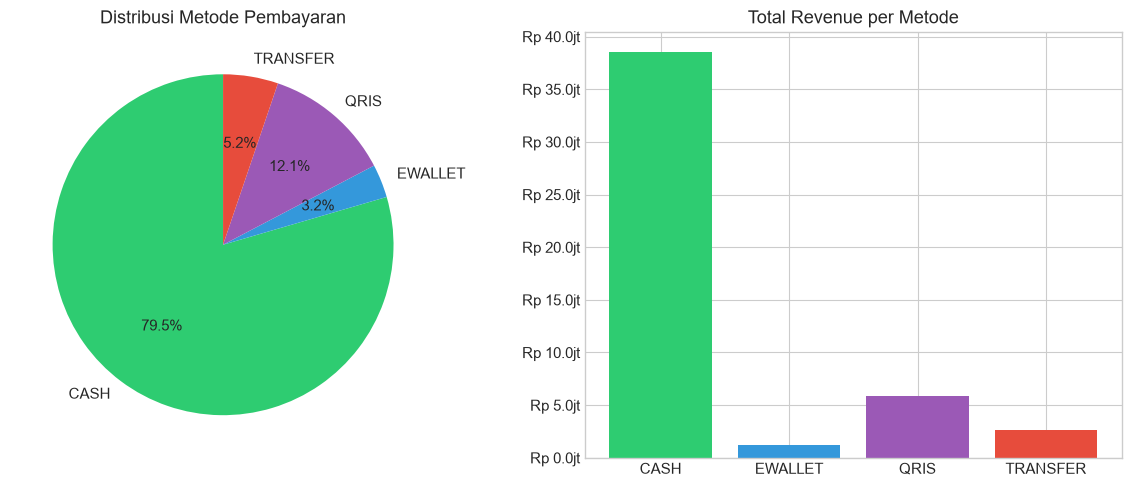

  method  count    total  pct
    CASH   1433 38539750 79.5
 EWALLET     57  1185800  3.2
    QRIS    218  5905200 12.1
TRANSFER     94  2620375  5.2


In [8]:
payment_stats = transactions.groupby('payment_method')['total'].agg(['count', 'sum']).reset_index()
payment_stats.columns = ['method', 'count', 'total']
payment_stats['pct'] = (payment_stats['count'] / payment_stats['count'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_pay = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

axes[0].pie(payment_stats['count'], labels=payment_stats['method'], autopct='%1.1f%%', colors=colors_pay, startangle=90)
axes[0].set_title('Distribusi Metode Pembayaran')

axes[1].bar(payment_stats['method'], payment_stats['total'], color=colors_pay)
axes[1].set_title('Total Revenue per Metode')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x/1e6:.1f}jt'))

plt.tight_layout()
plt.savefig('data/eda_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print(payment_stats.to_string(index=False))

## 6. Korelasi Fitur untuk ML
Melihat fitur mana yang paling berpengaruh terhadap revenue harian.

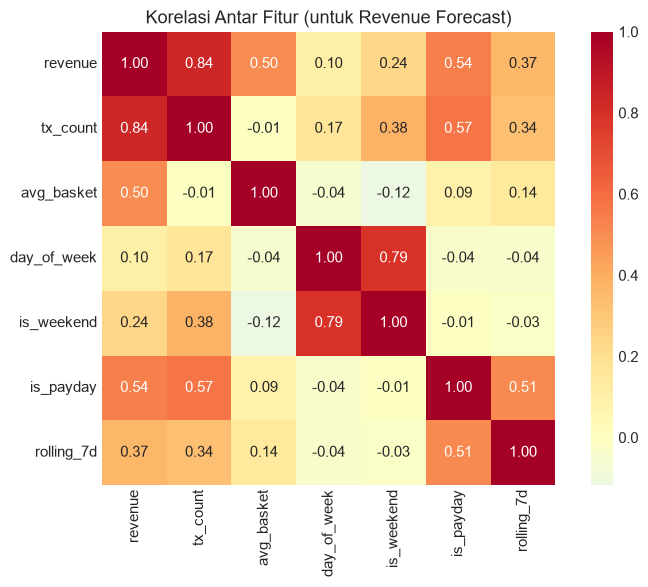


Korelasi dengan Revenue:
  tx_count: 0.836
  is_payday: 0.537
  avg_basket: 0.505
  rolling_7d: 0.365
  is_weekend: 0.237
  day_of_week: 0.102


In [9]:
# Buat daily features
daily_features = transactions.groupby('date').agg(
    revenue=('total', 'sum'),
    tx_count=('total', 'count'),
    avg_basket=('total', 'mean'),
    day_of_week=('day_of_week', 'first'),
    is_weekend=('is_weekend', 'first'),
    is_payday=('is_payday', 'first')
).reset_index()

daily_features['rolling_7d'] = daily_features['revenue'].rolling(7).mean()
daily_features = daily_features.dropna()

corr_cols = ['revenue', 'tx_count', 'avg_basket', 'day_of_week', 'is_weekend', 'is_payday', 'rolling_7d']
corr = daily_features[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', square=True)
plt.title('Korelasi Antar Fitur (untuk Revenue Forecast)')
plt.tight_layout()
plt.savefig('data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan Revenue:')
rev_corr = corr['revenue'].drop('revenue').sort_values(ascending=False)
for feat, val in rev_corr.items():
    print(f'  {feat}: {val:.3f}')

## 7. Kesimpulan EDA

Berdasarkan eksplorasi data, ditemukan:

1. **Data terdiri dari 24 produk** dari 7 kategori, dikompilasi dari wawancara 11 UMKM di Semarang
2. **Revenue rata-rata** ~Rp 530.000/hari dengan ~20 transaksi/hari — realistis untuk warung kelontong
3. **Pola weekend** terlihat jelas: peningkatan revenue pada Sabtu-Minggu
4. **Klasifikasi ABC** menunjukkan ~5-6 produk (Kelas A) menyumbang ~80% revenue
5. **Metode pembayaran**: CASH dominan (~80%), diikuti QRIS (~12%)
6. **Fitur untuk ML**: `tx_count`, `is_weekend`, `is_payday`, dan `rolling_7d` berkorelasi dengan revenue

### Rekomendasi Model
- **Revenue Forecast**: Gunakan Ridge Regression dengan 4 fitur engineered
- **Stockout**: Moving Average sederhana cukup efektif
- **ABC**: Pareto Analysis standar
- **Restock**: Safety Stock + EOQ
- **Expiry Risk**: Sales Velocity analysis